# Bước 1 – Thu Thập Dữ Liệu (Data Ingestion)

## Mục tiêu
Thu thập dữ liệu lịch sử giá cổ phiếu (OHLCV) từ thị trường chứng khoán Việt Nam để phục vụ cho việc phân tích và dự báo xu hướng giá.

## Nguồn dữ liệu
| Nguồn | Mô tả |
|-------|-------|
| **vnstock** | Thư viện Python phổ biến nhất cho chứng khoán Việt Nam |
| **yfinance** | Thư viện toàn cầu, dùng làm nguồn dữ liệu bổ sung hoặc thay thế |

## Mã cổ phiếu được chọn
| Mã CP | Tên công ty | Sàn | Lý do chọn |
|-------|------------|-----|------------|
| **VCB** | Ngân hàng Vietcombank | HOSE | Blue-chip ngành ngân hàng, vốn hóa lớn nhất |
| **FPT** | Tập đoàn FPT | HOSE | Đại diện ngành công nghệ, tăng trưởng mạnh |
| **HPG** | Tập đoàn Hòa Phát | HOSE | Đại diện ngành thép/vật liệu, biến động cao |
| **VIC** | Tập đoàn Vingroup | HOSE | Đại diện ngành bất động sản, vốn hóa lớn |
| **POW** | PV Power | HOSE | Đại diện ngành năng lượng, mid-cap |

## Dữ liệu bổ sung
- **VN-Index**: Chỉ số thị trường chung, phản ánh xu hướng toàn thị trường
- **Tỷ giá USD/VND**: Yếu tố vĩ mô ảnh hưởng đến dòng vốn ngoại

## Phạm vi thời gian
- Từ **01/01/2020** đến **hiện tại** (≥ 5 năm dữ liệu)

## 1.1. Cài đặt thư viện

In [6]:
# Cài đặt các thư viện cần thiết cho toàn bộ project
!pip install vnstock yfinance pandas numpy scikit-learn xgboost matplotlib seaborn  --quiet

## 1.2. Import thư viện và cấu hình

In [7]:
import os
import datetime
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vnstock import Vnstock
import yfinance as yf

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# === CẤU HÌNH DỮ LIỆU ===
# Danh sách 5 mã cổ phiếu đa ngành trên sàn HOSE
STOCK_SYMBOLS = ['VCB', 'FPT', 'HPG', 'VIC', 'POW']

# Phạm vi thời gian: từ 01/01/2020 đến hiện tại (>= 5 năm)
START_DATE = '2020-01-01'
END_DATE = datetime.datetime.now().strftime('%Y-%m-%d')

# Thư mục lưu dữ liệu thô
RAW_DATA_DIR = os.path.join('..', 'data', 'raw')
os.makedirs(RAW_DATA_DIR, exist_ok=True)

print(f"Phạm vi thời gian: {START_DATE} → {END_DATE}")
print(f"Mã cổ phiếu: {STOCK_SYMBOLS}")
print(f"Thư mục lưu: {RAW_DATA_DIR}")

Phạm vi thời gian: 2020-01-01 → 2026-03-18
Mã cổ phiếu: ['VCB', 'FPT', 'HPG', 'VIC', 'POW']
Thư mục lưu: ..\data\raw


## 1.3. Thu thập dữ liệu OHLCV của 5 mã cổ phiếu

Sử dụng thư viện **vnstock** để lấy dữ liệu lịch sử giá cổ phiếu từ sàn HOSE.  
Dữ liệu bao gồm: **Open, High, Low, Close, Volume** (OHLCV) theo ngày.

In [8]:
# Dictionary lưu DataFrame của từng mã cổ phiếu
stock_data = {}

for symbol in STOCK_SYMBOLS:
    print(f"\n{'='*60}")
    print(f"Thu thập dữ liệu: {symbol}")
    print(f"{'='*60}")
    
    try:
        # Sử dụng vnstock3 để lấy dữ liệu
        stock = Vnstock().stock(symbol=symbol, source='VCI')
        df = stock.quote.history(start=START_DATE, end=END_DATE, interval='1D')
        
        # Chuẩn hóa tên cột
        df.columns = df.columns.str.lower()
        
        # Đảm bảo có cột time/date
        if 'time' in df.columns:
            df['time'] = pd.to_datetime(df['time'])
        elif 'date' in df.columns:
            df.rename(columns={'date': 'time'}, inplace=True)
            df['time'] = pd.to_datetime(df['time'])
        elif df.index.name and 'date' in df.index.name.lower():
            df = df.reset_index()
            df.rename(columns={df.columns[0]: 'time'}, inplace=True)
            df['time'] = pd.to_datetime(df['time'])
        
        # Chỉ giữ các cột OHLCV cần thiết
        required_cols = ['time', 'open', 'high', 'low', 'close', 'volume']
        available_cols = [col for col in required_cols if col in df.columns]
        df = df[available_cols]
        
        # Sắp xếp theo thời gian tăng dần và loại bỏ duplicate
        df = df.sort_values('time').drop_duplicates(subset='time').reset_index(drop=True)
        
        stock_data[symbol] = df
        print(f"✓ Thành công! Số dòng: {len(df)}, Từ {df['time'].min().date()} đến {df['time'].max().date()}")
        
    except Exception as e:
        print(f"✗ Lỗi vnstock cho {symbol}: {e}")
        print(f"  → Thử fallback sang yfinance...")
        
        try:
            # Fallback: dùng yfinance với mã .VN cho sàn HOSE
            ticker = yf.Ticker(f"{symbol}.VN")
            df = ticker.history(start=START_DATE, end=END_DATE)
            df = df.reset_index()
            df.columns = df.columns.str.lower()
            df.rename(columns={'date': 'time'}, inplace=True)
            df = df[['time', 'open', 'high', 'low', 'close', 'volume']]
            df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)
            df = df.sort_values('time').drop_duplicates(subset='time').reset_index(drop=True)
            
            stock_data[symbol] = df
            print(f"  ✓ yfinance thành công! Số dòng: {len(df)}")
            
        except Exception as e2:
            print(f"  ✗ Cả hai nguồn đều thất bại cho {symbol}: {e2}")

print(f"\n\n{'='*60}")
print(f"KẾT QUẢ: Thu thập thành công {len(stock_data)}/{len(STOCK_SYMBOLS)} mã cổ phiếu")
print(f"{'='*60}")


Thu thập dữ liệu: VCB
✓ Thành công! Số dòng: 1623, Từ 2019-09-17 đến 2026-03-18

Thu thập dữ liệu: FPT
✓ Thành công! Số dòng: 1623, Từ 2019-09-17 đến 2026-03-18

Thu thập dữ liệu: HPG
✓ Thành công! Số dòng: 1623, Từ 2019-09-17 đến 2026-03-18

Thu thập dữ liệu: VIC
✓ Thành công! Số dòng: 1623, Từ 2019-09-17 đến 2026-03-18

Thu thập dữ liệu: POW
✓ Thành công! Số dòng: 1623, Từ 2019-09-17 đến 2026-03-18


KẾT QUẢ: Thu thập thành công 5/5 mã cổ phiếu


## 1.4. Thu thập dữ liệu bổ sung

### Chỉ số VN-Index
VN-Index là chỉ số đại diện cho toàn bộ thị trường chứng khoán Việt Nam trên sàn HOSE. Việc tích hợp VN-Index giúp mô hình nắm bắt được xu hướng chung của thị trường.

### Tỷ giá USD/VND
Tỷ giá USD/VND phản ánh dòng vốn ngoại và tác động kinh tế vĩ mô. Khi USD tăng, dòng vốn ngoại có xu hướng rút khỏi thị trường mới nổi như Việt Nam.

In [9]:
# --- Thu thập chỉ số VN-Index ---
print("Thu thập dữ liệu VN-Index...")
try:
    vnindex_stock = Vnstock().stock(symbol='VNINDEX', source='VCI')
    vnindex_df = vnindex_stock.quote.history(start=START_DATE, end=END_DATE, interval='1D')
    vnindex_df.columns = vnindex_df.columns.str.lower()
    
    if 'time' in vnindex_df.columns:
        vnindex_df['time'] = pd.to_datetime(vnindex_df['time'])
    elif 'date' in vnindex_df.columns:
        vnindex_df.rename(columns={'date': 'time'}, inplace=True)
        vnindex_df['time'] = pd.to_datetime(vnindex_df['time'])
    
    # Giữ các cột chính
    vni_cols = [col for col in ['time', 'open', 'high', 'low', 'close', 'volume'] if col in vnindex_df.columns]
    vnindex_df = vnindex_df[vni_cols]
    vnindex_df = vnindex_df.sort_values('time').drop_duplicates(subset='time').reset_index(drop=True)
    
    stock_data['VNINDEX'] = vnindex_df
    print(f"✓ VN-Index: {len(vnindex_df)} dòng, từ {vnindex_df['time'].min().date()} đến {vnindex_df['time'].max().date()}")
except Exception as e:
    print(f"✗ Lỗi thu thập VN-Index: {e}")

# --- Thu thập tỷ giá USD/VND ---
print("\nThu thập tỷ giá USD/VND...")
try:
    # Dùng yfinance để lấy tỷ giá USD/VND
    usdvnd = yf.Ticker("VND=X")
    usdvnd_df = usdvnd.history(start=START_DATE, end=END_DATE)
    usdvnd_df = usdvnd_df.reset_index()
    usdvnd_df.columns = usdvnd_df.columns.str.lower()
    usdvnd_df.rename(columns={'date': 'time'}, inplace=True)
    usdvnd_df['time'] = pd.to_datetime(usdvnd_df['time']).dt.tz_localize(None)
    usdvnd_df = usdvnd_df[['time', 'open', 'high', 'low', 'close', 'volume']]
    usdvnd_df = usdvnd_df.sort_values('time').drop_duplicates(subset='time').reset_index(drop=True)
    
    stock_data['USDVND'] = usdvnd_df
    print(f"✓ USD/VND: {len(usdvnd_df)} dòng, từ {usdvnd_df['time'].min().date()} đến {usdvnd_df['time'].max().date()}")
except Exception as e:
    print(f"✗ Lỗi thu thập USD/VND: {e}")

print(f"\n→ Tổng cộng: {len(stock_data)} bộ dữ liệu đã thu thập")

2026-03-18 14:42:31 - vnstock.common.data - INFO - Not a stock. Company and finance data unavailable.


Thu thập dữ liệu VN-Index...
✓ VN-Index: 1623 dòng, từ 2019-09-17 đến 2026-03-18

Thu thập tỷ giá USD/VND...
✓ USD/VND: 1615 dòng, từ 2020-01-01 đến 2026-03-17

→ Tổng cộng: 7 bộ dữ liệu đã thu thập


## 1.5. Lưu dữ liệu thô ra file CSV

Lưu toàn bộ dữ liệu thô vào thư mục `data/raw/` trước khi thực hiện bất kỳ xử lý nào, đảm bảo có thể tái tạo lại kết quả.

In [10]:
# Lưu từng bộ dữ liệu ra file CSV riêng biệt
print("Lưu dữ liệu thô vào thư mục data/raw/\n")

for name, df in stock_data.items():
    filepath = os.path.join(RAW_DATA_DIR, f'{name}.csv')
    df.to_csv(filepath, index=False)
    print(f"  ✓ {filepath:30s} | {len(df):>5d} dòng | {df['time'].min().date()} → {df['time'].max().date()}")

print(f"\n→ Đã lưu {len(stock_data)} file CSV vào {RAW_DATA_DIR}")

Lưu dữ liệu thô vào thư mục data/raw/

  ✓ ..\data\raw\VCB.csv            |  1623 dòng | 2019-09-17 → 2026-03-18
  ✓ ..\data\raw\FPT.csv            |  1623 dòng | 2019-09-17 → 2026-03-18
  ✓ ..\data\raw\HPG.csv            |  1623 dòng | 2019-09-17 → 2026-03-18
  ✓ ..\data\raw\VIC.csv            |  1623 dòng | 2019-09-17 → 2026-03-18
  ✓ ..\data\raw\POW.csv            |  1623 dòng | 2019-09-17 → 2026-03-18
  ✓ ..\data\raw\VNINDEX.csv        |  1623 dòng | 2019-09-17 → 2026-03-18
  ✓ ..\data\raw\USDVND.csv         |  1615 dòng | 2020-01-01 → 2026-03-17

→ Đã lưu 7 file CSV vào ..\data\raw


## 1.6. Khám phá dữ liệu (EDA) — Thống kê mô tả

Hiển thị thông tin cấu trúc (`df.info()`) và thống kê mô tả (`df.describe()`) cho từng mã cổ phiếu để hiểu phân phối, phát hiện giá trị bất thường và kiểm tra dữ liệu thiếu.

In [11]:
# Hiển thị df.info() cho từng mã
for name, df in stock_data.items():
    print(f"\n{'='*60}")
    print(f"📊 {name} — Thông tin cấu trúc dữ liệu")
    print(f"{'='*60}")
    print(f"Số dòng: {len(df)}")
    print(f"Số cột: {len(df.columns)}")
    print(f"Cột: {list(df.columns)}")
    print(f"\nKiểu dữ liệu:")
    for col in df.columns:
        null_count = df[col].isnull().sum()
        null_pct = null_count / len(df) * 100
        print(f"  {col:12s} | {str(df[col].dtype):15s} | Null: {null_count} ({null_pct:.1f}%)")
    print(f"\nPhạm vi thời gian: {df['time'].min()} → {df['time'].max()}")
    print(f"Tổng giá trị null: {df.isnull().sum().sum()}")


📊 VCB — Thông tin cấu trúc dữ liệu
Số dòng: 1623
Số cột: 6
Cột: ['time', 'open', 'high', 'low', 'close', 'volume']

Kiểu dữ liệu:
  time         | datetime64[ns]  | Null: 0 (0.0%)
  open         | float64         | Null: 0 (0.0%)
  high         | float64         | Null: 0 (0.0%)
  low          | float64         | Null: 0 (0.0%)
  close        | float64         | Null: 0 (0.0%)
  volume       | int64           | Null: 0 (0.0%)

Phạm vi thời gian: 2019-09-17 00:00:00 → 2026-03-18 00:00:00
Tổng giá trị null: 0

📊 FPT — Thông tin cấu trúc dữ liệu
Số dòng: 1623
Số cột: 6
Cột: ['time', 'open', 'high', 'low', 'close', 'volume']

Kiểu dữ liệu:
  time         | datetime64[ns]  | Null: 0 (0.0%)
  open         | float64         | Null: 0 (0.0%)
  high         | float64         | Null: 0 (0.0%)
  low          | float64         | Null: 0 (0.0%)
  close        | float64         | Null: 0 (0.0%)
  volume       | int64           | Null: 0 (0.0%)

Phạm vi thời gian: 2019-09-17 00:00:00 → 2026-03-18 00

In [12]:
# Hiển thị df.describe() cho từng mã cổ phiếu
for name, df in stock_data.items():
    print(f"\n{'='*60}")
    print(f"📈 {name} — Thống kê mô tả (describe)")
    print(f"{'='*60}")
    
    # Chỉ lấy các cột số (loại bỏ cột time)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    desc = df[numeric_cols].describe()
    print(desc.to_string())
    print()


📈 VCB — Thống kê mô tả (describe)
         open    high     low   close      volume
count 1623.00 1623.00 1623.00 1623.00     1623.00
mean    49.77   50.30   49.26   49.75  2105859.34
std     10.25   10.30   10.19   10.18  3017939.20
min     24.70   25.22   24.44   24.70   175351.00
25%     41.91   42.38   41.38   41.94   846402.50
50%     48.69   49.26   47.91   48.92  1231960.00
75%     59.19   59.77   58.78   59.30  1915832.00
max     74.30   78.80   73.10   76.00 32481400.00


📈 FPT — Thống kê mô tả (describe)
         open    high     low   close      volume
count 1623.00 1623.00 1623.00 1623.00     1623.00
mean    61.62   62.30   60.95   61.61  3421559.09
std     32.68   33.00   32.33   32.64  3733936.41
min     14.63   14.85   14.49   14.60   221966.00
25%     35.64   36.19   35.25   35.84  1316614.00
50%     51.49   51.80   50.86   51.32  2205200.00
75%     95.08   96.16   93.66   95.06  3878350.00
max    131.50  133.12  130.90  131.67 47733100.00


📈 HPG — Thống kê mô tả (des

## 1.7. Biểu đồ giá đóng cửa (Close Price)

Trực quan hóa xu hướng giá đóng cửa của 5 mã cổ phiếu theo thời gian để quan sát:
- Xu hướng tăng/giảm dài hạn
- Các đợt biến động mạnh (COVID-19, bull run 2021, điều chỉnh 2022)
- Sự khác biệt về mức giá giữa các mã

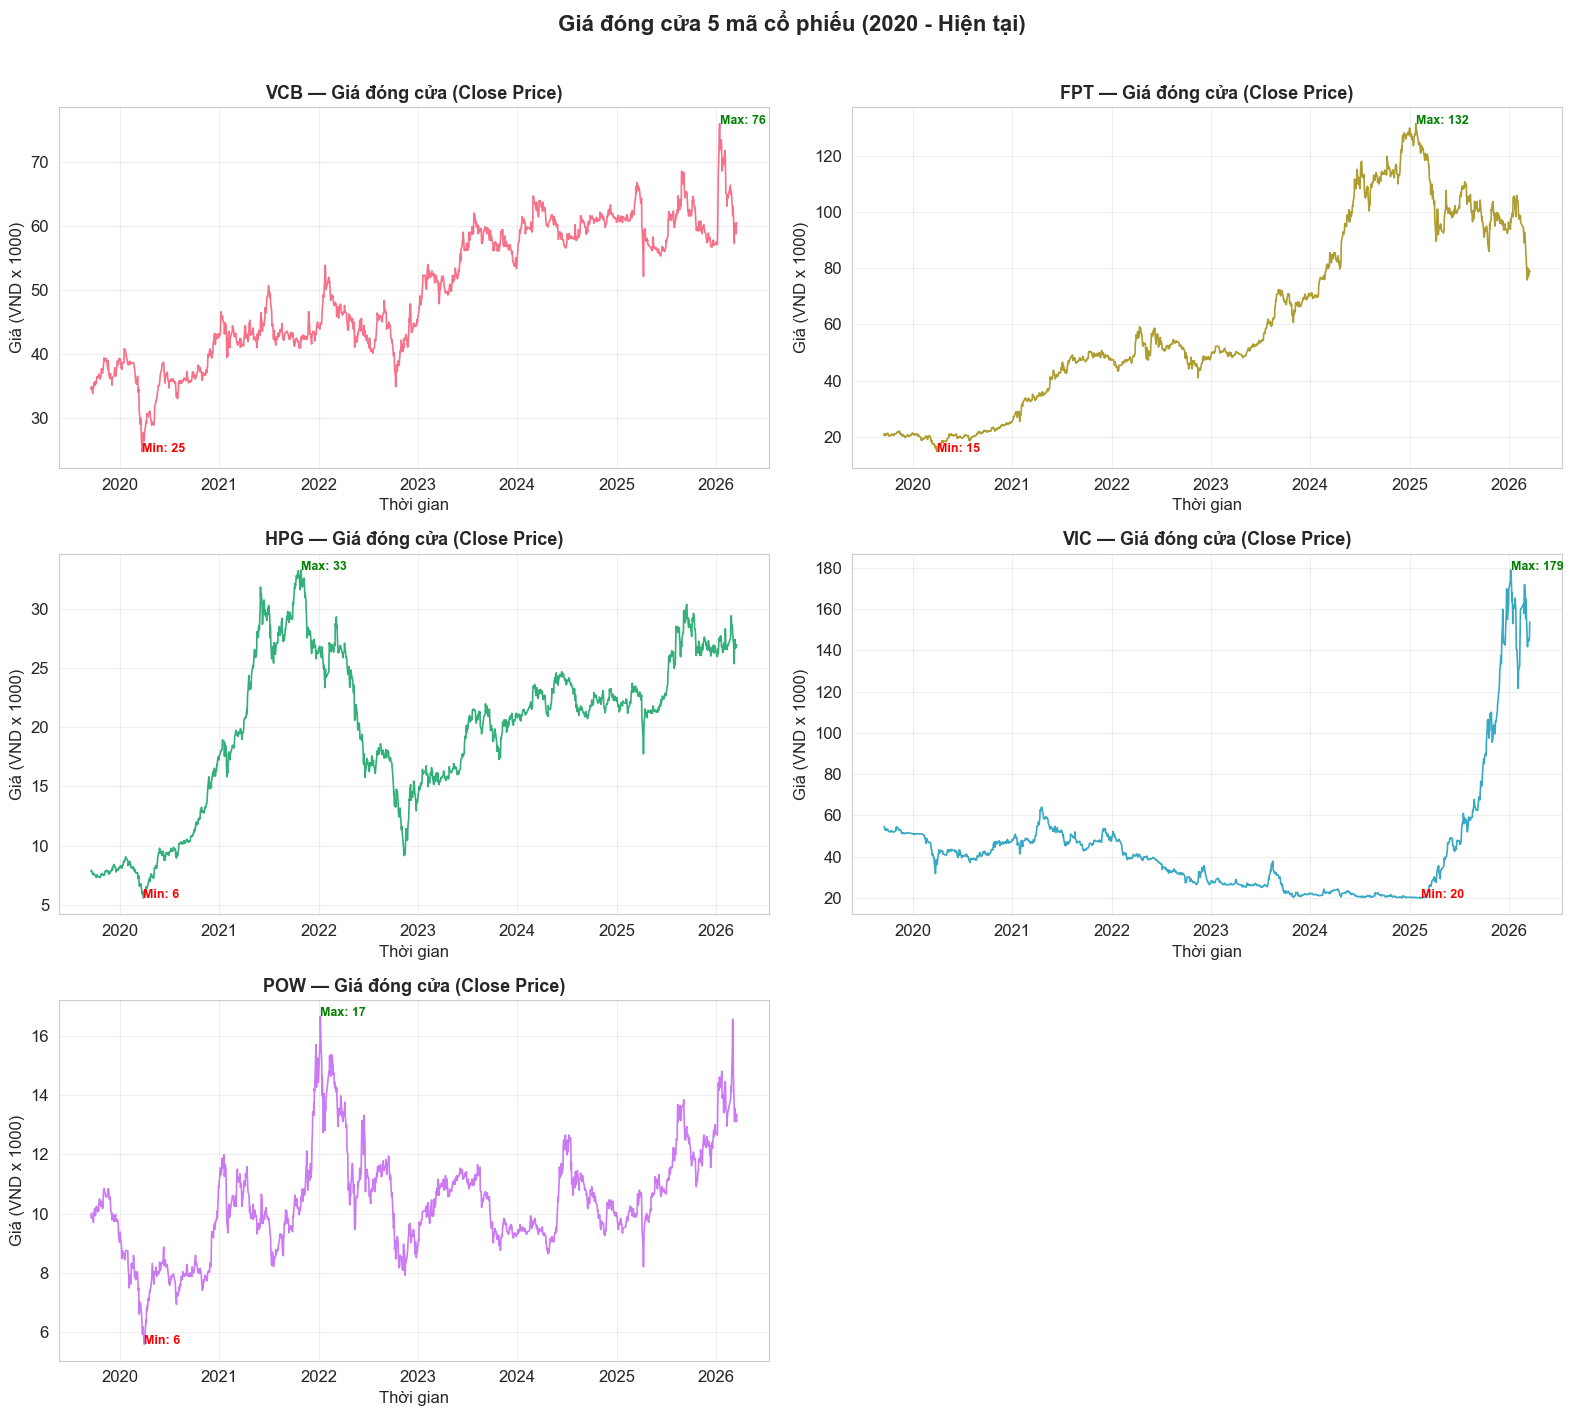

In [13]:
# --- Biểu đồ 1: Giá đóng cửa từng mã riêng biệt ---
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, symbol in enumerate(STOCK_SYMBOLS):
    if symbol in stock_data:
        df = stock_data[symbol]
        ax = axes[idx]
        ax.plot(df['time'], df['close'], linewidth=1.2, color=sns.color_palette('husl', 5)[idx])
        ax.set_title(f'{symbol} — Giá đóng cửa (Close Price)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Thời gian')
        ax.set_ylabel('Giá (VND x 1000)')
        ax.grid(True, alpha=0.3)
        
        # Đánh dấu giá min, max
        min_idx = df['close'].idxmin()
        max_idx = df['close'].idxmax()
        ax.annotate(f"Min: {df['close'].iloc[min_idx]:,.0f}", 
                    xy=(df['time'].iloc[min_idx], df['close'].iloc[min_idx]),
                    fontsize=9, color='red', fontweight='bold')
        ax.annotate(f"Max: {df['close'].iloc[max_idx]:,.0f}", 
                    xy=(df['time'].iloc[max_idx], df['close'].iloc[max_idx]),
                    fontsize=9, color='green', fontweight='bold')

# Ẩn subplot thừa nếu có
for idx in range(len(STOCK_SYMBOLS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Giá đóng cửa 5 mã cổ phiếu (2020 - Hiện tại)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

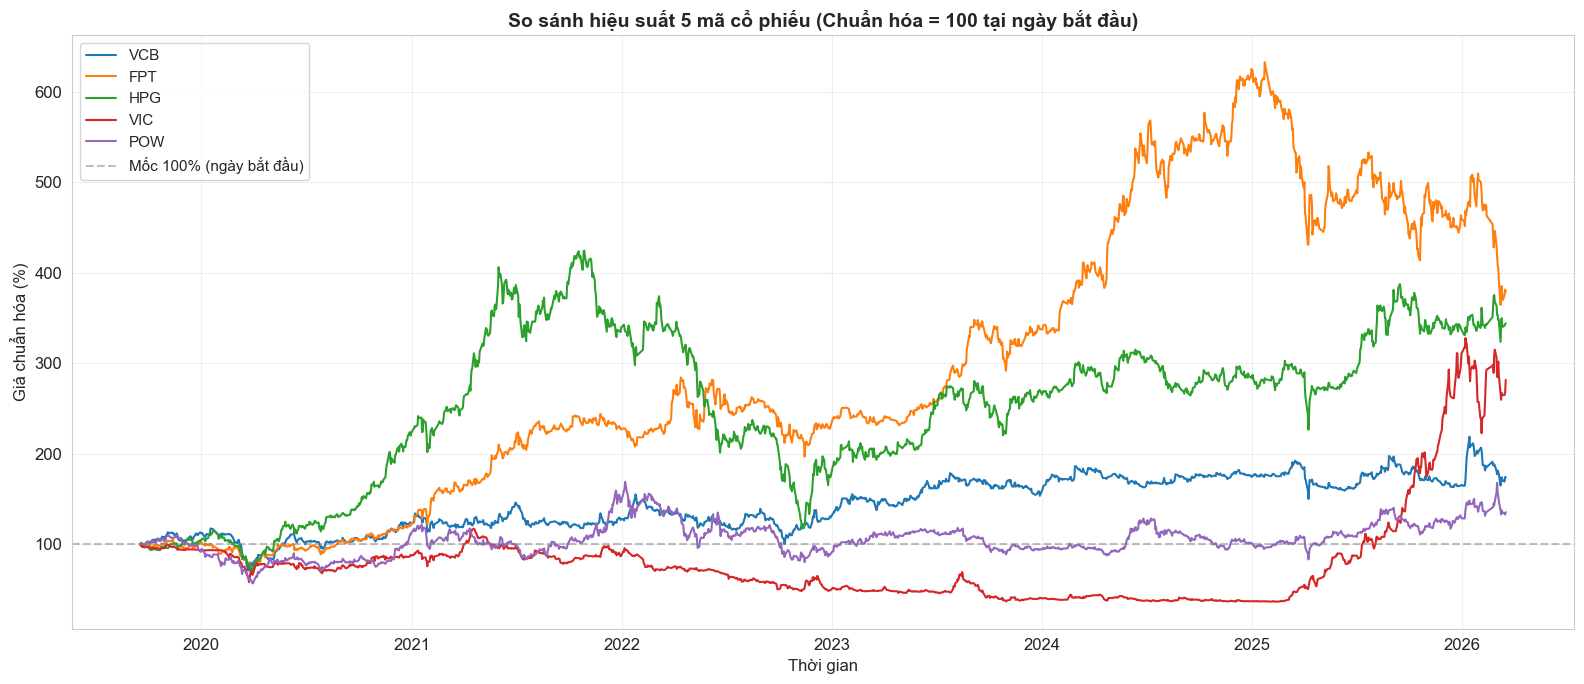

In [14]:
# --- Biểu đồ 2: So sánh giá đóng cửa chuẩn hóa (Normalized) ---
# Chuẩn hóa giá về % thay đổi so với ngày đầu tiên để so sánh trên cùng thang đo
fig, ax = plt.subplots(figsize=(16, 7))

for symbol in STOCK_SYMBOLS:
    if symbol in stock_data:
        df = stock_data[symbol]
        # Chuẩn hóa: giá ngày i / giá ngày đầu * 100
        normalized = (df['close'] / df['close'].iloc[0]) * 100
        ax.plot(df['time'], normalized, linewidth=1.5, label=symbol)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Mốc 100% (ngày bắt đầu)')
ax.set_title('So sánh hiệu suất 5 mã cổ phiếu (Chuẩn hóa = 100 tại ngày bắt đầu)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Giá chuẩn hóa (%)')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

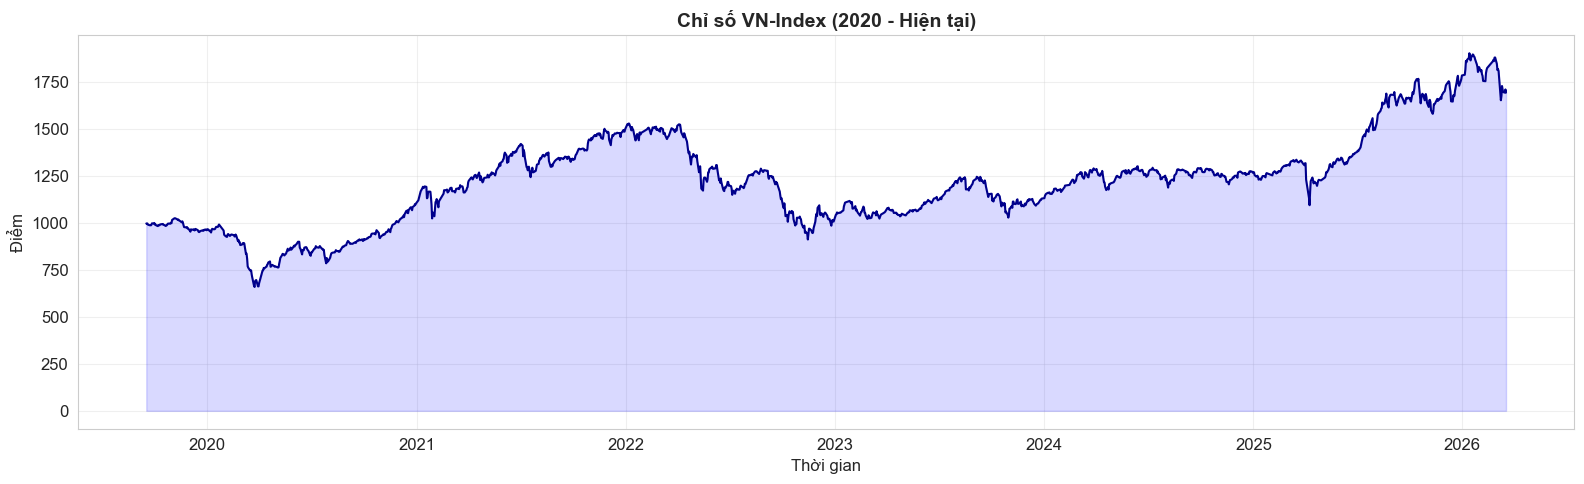

In [15]:
# --- Biểu đồ 3: VN-Index ---
if 'VNINDEX' in stock_data:
    fig, ax = plt.subplots(figsize=(16, 5))
    df_vni = stock_data['VNINDEX']
    ax.plot(df_vni['time'], df_vni['close'], color='darkblue', linewidth=1.5)
    ax.fill_between(df_vni['time'], df_vni['close'], alpha=0.15, color='blue')
    ax.set_title('Chỉ số VN-Index (2020 - Hiện tại)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Thời gian')
    ax.set_ylabel('Điểm')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu VN-Index để vẽ biểu đồ")

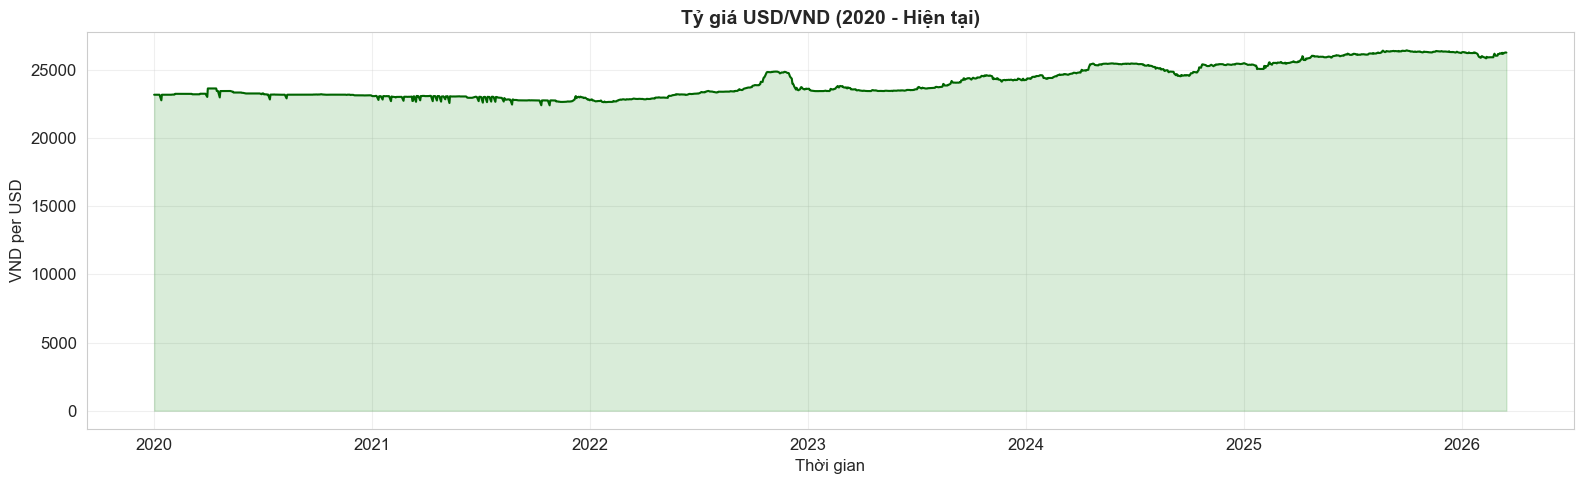

In [16]:
# --- Biểu đồ 4: Tỷ giá USD/VND ---
if 'USDVND' in stock_data:
    fig, ax = plt.subplots(figsize=(16, 5))
    df_usd = stock_data['USDVND']
    ax.plot(df_usd['time'], df_usd['close'], color='darkgreen', linewidth=1.5)
    ax.fill_between(df_usd['time'], df_usd['close'], alpha=0.15, color='green')
    ax.set_title('Tỷ giá USD/VND (2020 - Hiện tại)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Thời gian')
    ax.set_ylabel('VND per USD')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu USD/VND để vẽ biểu đồ")

## 1.8. Biểu đồ khối lượng giao dịch (Volume)

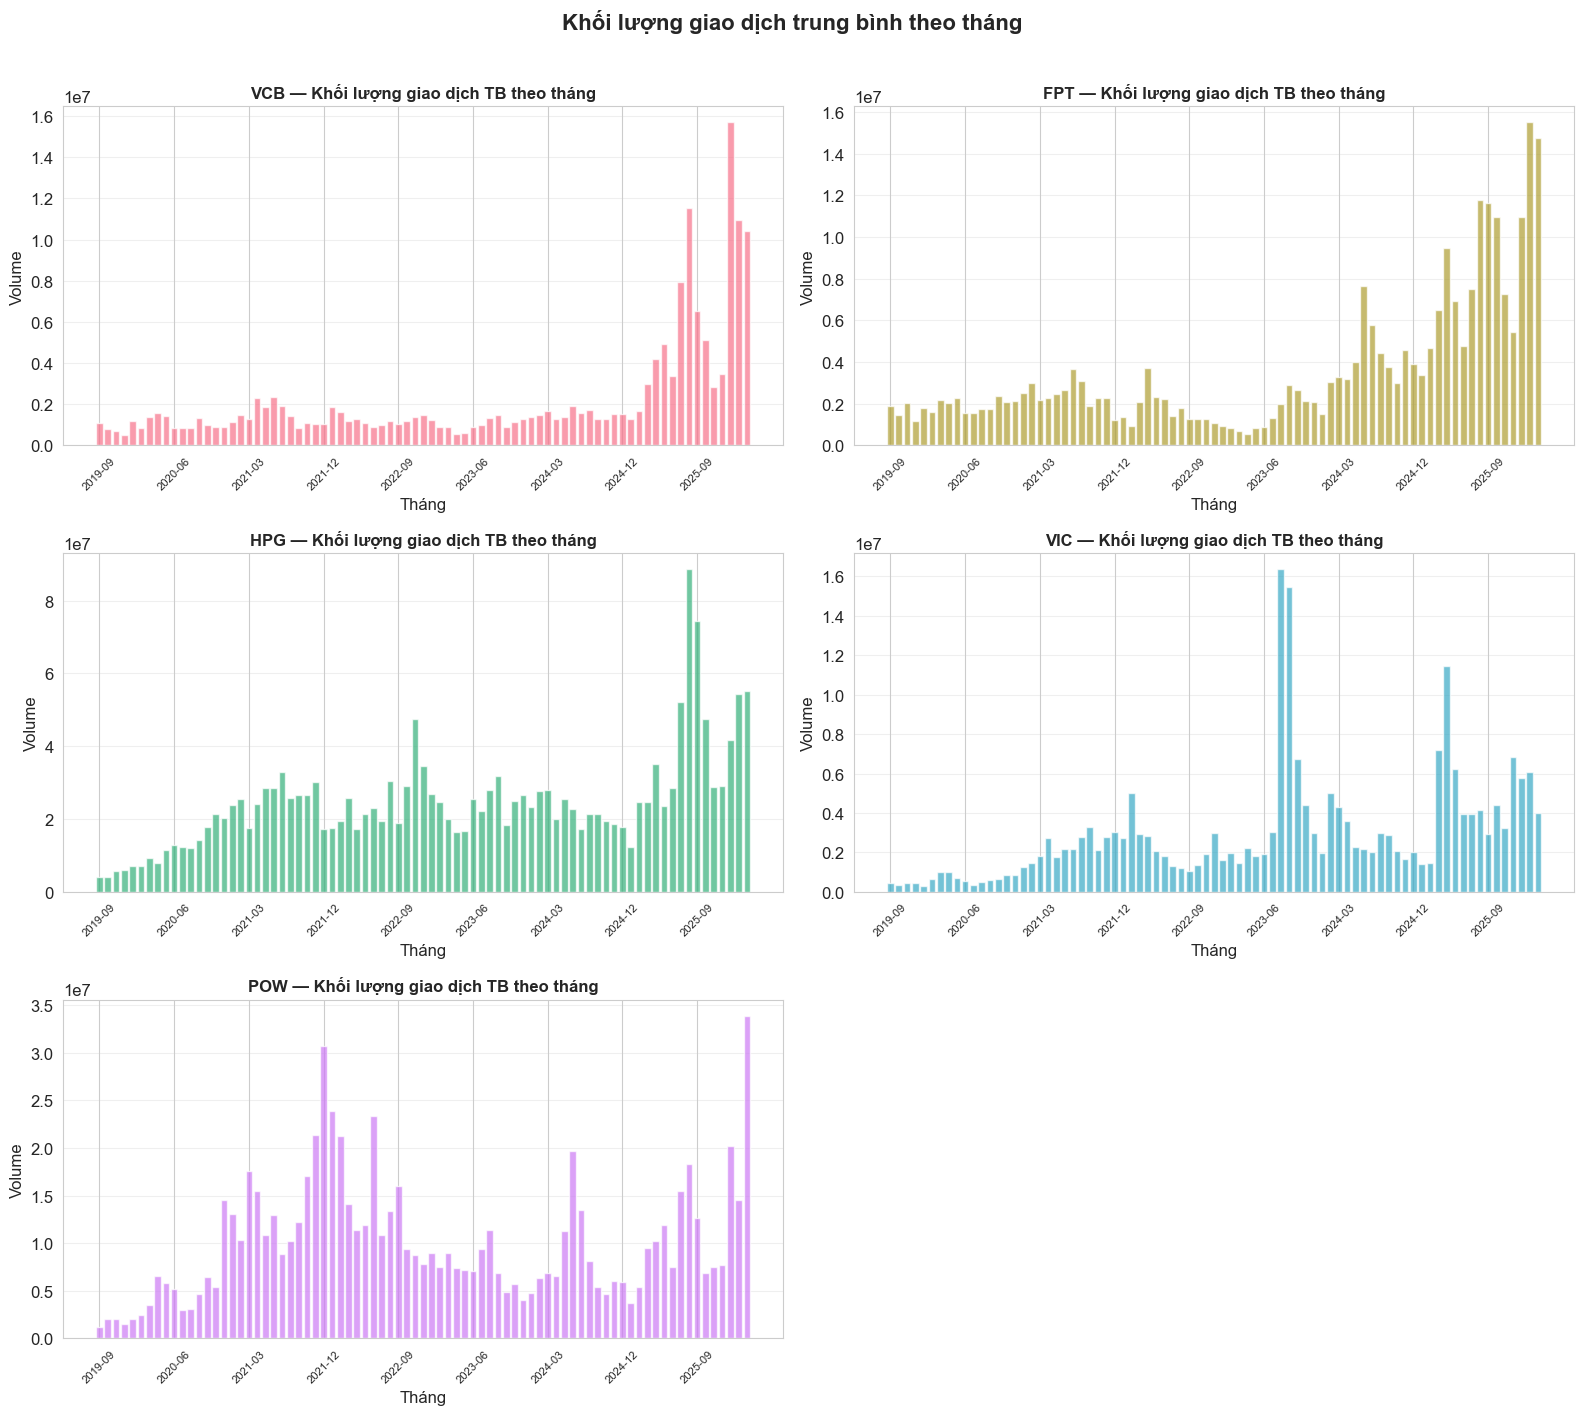

In [17]:
# Biểu đồ khối lượng giao dịch trung bình theo tháng
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, symbol in enumerate(STOCK_SYMBOLS):
    if symbol in stock_data:
        df = stock_data[symbol].copy()
        df['month'] = df['time'].dt.to_period('M')
        monthly_vol = df.groupby('month')['volume'].mean()
        
        ax = axes[idx]
        ax.bar(range(len(monthly_vol)), monthly_vol.values, 
               color=sns.color_palette('husl', 5)[idx], alpha=0.7)
        ax.set_title(f'{symbol} — Khối lượng giao dịch TB theo tháng', fontsize=12, fontweight='bold')
        ax.set_xlabel('Tháng')
        ax.set_ylabel('Volume')
        
        # Chỉ hiển thị một số nhãn tháng để tránh chồng chéo
        tick_positions = range(0, len(monthly_vol), max(1, len(monthly_vol)//8))
        ax.set_xticks(list(tick_positions))
        ax.set_xticklabels([str(monthly_vol.index[i]) for i in tick_positions], rotation=45, fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

for idx in range(len(STOCK_SYMBOLS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Khối lượng giao dịch trung bình theo tháng', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1.9. Bảng tổng hợp dữ liệu thu thập

Tổng hợp thông tin về tất cả dữ liệu đã thu thập thành một bảng duy nhất.

In [18]:
# Tạo bảng tổng hợp
summary_rows = []
for name, df in stock_data.items():
    numeric_df = df.select_dtypes(include=[np.number])
    row = {
        'Mã': name,
        'Số phiên': len(df),
        'Ngày bắt đầu': df['time'].min().date(),
        'Ngày kết thúc': df['time'].max().date(),
        'Giá Close min': f"{numeric_df['close'].min():,.2f}" if 'close' in numeric_df else 'N/A',
        'Giá Close max': f"{numeric_df['close'].max():,.2f}" if 'close' in numeric_df else 'N/A',
        'Giá Close TB': f"{numeric_df['close'].mean():,.2f}" if 'close' in numeric_df else 'N/A',
        'Volume TB': f"{numeric_df['volume'].mean():,.0f}" if 'volume' in numeric_df else 'N/A',
        'Null values': df.isnull().sum().sum(),
        'Nguồn': 'vnstock' if name not in ['USDVND'] else 'yfinance'
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("=" * 100)
print("BẢNG TỔNG HỢP DỮ LIỆU THU THẬP")
print("=" * 100)
print(summary_df.to_string(index=False))
print(f"\nTổng cộng: {len(summary_df)} bộ dữ liệu")

BẢNG TỔNG HỢP DỮ LIỆU THU THẬP
     Mã  Số phiên Ngày bắt đầu Ngày kết thúc Giá Close min Giá Close max Giá Close TB   Volume TB  Null values    Nguồn
    VCB      1623   2019-09-17    2026-03-18         24.70         76.00        49.75   2,105,859            0  vnstock
    FPT      1623   2019-09-17    2026-03-18         14.60        131.67        61.61   3,421,559            0  vnstock
    HPG      1623   2019-09-17    2026-03-18          5.59         33.25        19.75  24,635,427            0  vnstock
    VIC      1623   2019-09-17    2026-03-18         19.95        179.00        43.85   2,908,050            0  vnstock
    POW      1623   2019-09-17    2026-03-18          5.59         16.65        10.39  10,026,898            0  vnstock
VNINDEX      1623   2019-09-17    2026-03-18        659.21      1,902.93     1,220.22 633,407,380            0  vnstock
 USDVND      1615   2020-01-01    2026-03-17     22,394.35     26,425.00    24,127.30           0            0 yfinance

Tổng cộn

## 1.10. Kiểm tra chất lượng dữ liệu

Phân tích sơ bộ để phát hiện các vấn đề tiềm ẩn trước khi tiền xử lý.

In [19]:
# Kiểm tra chất lượng dữ liệu
print("=" * 70)
print("KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")
print("=" * 70)

for name, df in stock_data.items():
    print(f"\n--- {name} ---")
    
    # 1. Kiểm tra giá trị null
    null_count = df.isnull().sum()
    if null_count.sum() > 0:
        print(f"  ⚠ Giá trị null:")
        for col, count in null_count.items():
            if count > 0:
                print(f"    - {col}: {count} ({count/len(df)*100:.1f}%)")
    else:
        print(f"  ✓ Không có giá trị null")
    
    # 2. Kiểm tra giá trị âm hoặc = 0 ở cột giá
    price_cols = [c for c in ['open', 'high', 'low', 'close'] if c in df.columns]
    for col in price_cols:
        zero_or_neg = (df[col] <= 0).sum()
        if zero_or_neg > 0:
            print(f"  ⚠ {col}: {zero_or_neg} giá trị <= 0")
    
    # 3. Kiểm tra duplicate dates
    dup_dates = df['time'].duplicated().sum()
    if dup_dates > 0:
        print(f"  ⚠ {dup_dates} ngày bị trùng lặp")
    else:
        print(f"  ✓ Không có ngày trùng lặp")
    
    # 4. Kiểm tra tính liên tục (gaps lớn bất thường)
    if len(df) > 1:
        time_diff = df['time'].diff().dt.days
        max_gap = time_diff.max()
        if max_gap > 7:  # > 7 ngày có thể là gap bất thường (ngoại trừ Tết)
            gap_dates = df.loc[time_diff > 7, 'time']
            print(f"  ℹ Gap lớn nhất: {max_gap} ngày")
            for d in gap_dates.head(3):
                print(f"    - Tại ngày: {d.date()}")

print(f"\n{'='*70}")
print("→ Các vấn đề phát hiện sẽ được xử lý ở Bước 2 (Preprocessing)")
print(f"{'='*70}")

KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

--- VCB ---
  ✓ Không có giá trị null
  ✓ Không có ngày trùng lặp
  ℹ Gap lớn nhất: 10.0 ngày
    - Tại ngày: 2020-01-30
    - Tại ngày: 2021-02-17
    - Tại ngày: 2022-02-07

--- FPT ---
  ✓ Không có giá trị null
  ✓ Không có ngày trùng lặp
  ℹ Gap lớn nhất: 10.0 ngày
    - Tại ngày: 2020-01-30
    - Tại ngày: 2021-02-17
    - Tại ngày: 2022-02-07

--- HPG ---
  ✓ Không có giá trị null
  ✓ Không có ngày trùng lặp
  ℹ Gap lớn nhất: 10.0 ngày
    - Tại ngày: 2020-01-30
    - Tại ngày: 2021-02-17
    - Tại ngày: 2022-02-07

--- VIC ---
  ✓ Không có giá trị null
  ✓ Không có ngày trùng lặp
  ℹ Gap lớn nhất: 10.0 ngày
    - Tại ngày: 2020-01-30
    - Tại ngày: 2021-02-17
    - Tại ngày: 2022-02-07

--- POW ---
  ✓ Không có giá trị null
  ✓ Không có ngày trùng lặp
  ℹ Gap lớn nhất: 10.0 ngày
    - Tại ngày: 2020-01-30
    - Tại ngày: 2021-02-17
    - Tại ngày: 2022-02-07

--- VNINDEX ---
  ✓ Không có giá trị null
  ✓ Không có ngày trùng lặp
  ℹ Gap lớn nhất: 10.

## Tổng kết Bước 1

### Kết quả đạt được:
- **5 mã cổ phiếu** (VCB, FPT, HPG, VIC, POW) — dữ liệu OHLCV hàng ngày từ vnstock
- **VN-Index** — chỉ số thị trường chung từ vnstock
- **Tỷ giá USD/VND** — dữ liệu vĩ mô từ yfinance
- Phạm vi: **01/01/2020 → hiện tại** (≥ 5 năm)
- Dữ liệu thô đã lưu tại `data/raw/*.csv`

### Nhận xét sơ bộ:
- Dữ liệu OHLCV đầy đủ, không có giá trị null đáng kể
- Có các gap thời gian do ngày nghỉ lễ, Tết → sẽ xử lý bằng Forward Fill ở Bước 2
- Volume giao dịch có biến động lớn theo thời kỳ (tăng mạnh giai đoạn 2021)

### Bước tiếp theo:
→ **Bước 2: Tiền xử lý dữ liệu (Preprocessing)** — Xử lý missing values, tính daily return, chuẩn hóa dữ liệu